# Functional connectivity analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
#data_dir = '/home/alexandresayal/mnt/DATAPOOL/VPMB/BIDS-VPMB-SPE'
tc_dir = os.path.join(data_dir,'derivatives','timecourses')
#output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['UA']
hrf_delay = 0 # in seconds
roi_list = ['left_mt','right_mt','left_v1','right_v1']

In [6]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

window_size_tr = 6 # size of the correlation window in volumes
step_size_tr = 1   # step size of the correlation window in volumes

df = pd.DataFrame(columns=['subject','tr','run','left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1','corr_mt','corr_v1'])

for ss,subject in enumerate(subject_list):
    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            # load timecourse
            #tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-zscoresample_ss.npy")
            #tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-psc.npy")
            tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-psc_detrend.npy")
            tc = np.load(tc_file)

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:,0:2], axis=1)
            tc_mean2 = np.mean(tc[:,2:4], axis=1)

            # initialize correlation vectors
            corr_mt = np.zeros(int((tc[:,0].shape[0]-window_size_tr)/step_size_tr))
            corr_v1 = np.zeros(int((tc[:,0].shape[0]-window_size_tr)/step_size_tr))

            # estimate windowed correlation between left and right mt
            for tt,tt_vol in enumerate(range(0,tc[:,0].shape[0]-window_size_tr,step_size_tr)):
                corr_mt[tt] = np.corrcoef(tc[:,0][tt_vol:tt_vol+window_size_tr],tc[:,1][tt_vol:tt_vol+window_size_tr])[0,1]
                corr_v1[tt] = np.corrcoef(tc[:,2][tt_vol:tt_vol+window_size_tr],tc[:,3][tt_vol:tt_vol+window_size_tr])[0,1]

            # add row to dataframe
            df.loc[len(df)] = [subject, tr, run, tc[:,0], tc[:,1], tc[:,2], tc[:,3], tc_mean1, tc_mean2, corr_mt, corr_v1]    

roi_list = ['left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1']

In [7]:
df

,subject,tr,run,left_mt,right_mt,left_v1,right_v1,bilateral_mt,bilateral_v1,corr_mt,corr_v1
0,sub-01,0.50,UA,"[-0.22502376, -0.75862014, -0.81892, 0.6557168...","[-0.29588887, -0.6328848, -1.0537118, -0.29287...","[0.007993267, 0.022420743, -0.31263652, -0.666...","[-0.061439723, -0.097172484, -0.0958057, -0.54...","[-0.26045632, -0.6957525, -0.9363159, 0.181421...","[-0.026723228, -0.03737587, -0.20422111, -0.60...","[0.8115215086648107, 0.7272282325693685, 0.830...","[0.943266662077711, 0.9543594200411416, 0.9346..."
1,sub-01,0.75,UA,"[-0.1484935, -0.16956916, 0.079313174, -0.1769...","[-0.14745189, -0.15049157, 0.3577576, 0.024255...","[0.06832045, 0.29584754, -1.2515142, -0.786156...","[-0.031186417, 0.1780903, -0.8298843, -0.43459...","[-0.1479727, -0.16003036, 0.2185354, -0.076326...","[0.018567018, 0.23696892, -1.0406992, -0.61037...","[0.6159483718782163, 0.6333025761723646, 0.510...","[0.9604088161096498, 0.974509624401947, 0.9781..."
2,sub-01,1.00,UA,"[0.031965997, -0.48273653, -0.8907577, 0.36385...","[0.061520167, 0.20370793, -0.8810853, 0.330087...","[-0.08184679, -0.25848472, -1.1230928, -0.5496...","[-0.018638223, 0.053932924, -0.9501851, -0.276...","[0.04674308, -0.1395143, -0.8859215, 0.3469732...","[-0.050242506, -0.1022759, -1.036639, -0.41311...","[0.8536320546904239, 0.8832512222690859, 0.904...","[0.8858258078661359, 0.8900385345528816, 0.935..."
3,sub-01,2.50,UA,"[-0.37241307, -0.5533644, -0.8987705, -0.64749...","[-0.5593146, -0.38626885, -0.79276997, 0.21441...","[-0.118400514, -0.6065576, -0.30131793, 1.4222...","[-0.13588795, -0.7827336, -0.43930644, 1.23786...","[-0.46586382, -0.46981663, -0.84577024, -0.216...","[-0.12714423, -0.69464564, -0.37031218, 1.3300...","[0.5550464078365482, 0.6633281842952621, 0.622...","[0.9938590656542315, 0.9940992956019172, 0.990..."
4,sub-02,0.50,UA,"[0.03159108, 0.39694837, -0.8714979, 0.0167620...","[0.09885405, 0.19240025, -0.51269156, -0.14231...","[0.18969432, 0.11383102, -0.111216284, 0.00378...","[0.2568193, 0.46569753, -0.478945, -0.5795565,...","[0.06522256, 0.2946743, -0.69209474, -0.062776...","[0.22325681, 0.28976429, -0.29508063, -0.28788...","[0.9415779266695241, 0.9450277577182535, 0.816...","[0.8314616030381046, 0.7518498222277162, 0.725..."
5,sub-02,0.75,UA,"[-0.050044052, -0.07861489, -0.61438787, -0.64...","[0.06749652, -0.097205535, -0.10130333, -0.269...","[-0.082796134, 0.078224994, -0.5599647, -0.421...","[-0.0523036, -0.099258624, -0.4690817, -0.7062...","[0.0087262355, -0.08791021, -0.3578456, -0.456...","[-0.06754987, -0.010516815, -0.5145232, -0.564...","[0.5657159926140162, 0.7794889711648558, 0.604...","[0.8371447847974678, 0.7951285953795342, 0.704..."
6,sub-02,1.00,UA,"[-0.09508178, -1.1542277, -1.1341574, -0.17950...","[0.14899692, -1.2343684, -0.9797818, -0.391660...","[0.038787037, -1.1393085, -0.7764846, -0.33127...","[0.25313842, -0.9710283, -0.63306755, -0.20025...","[0.026957572, -1.194298, -1.0569696, -0.285580...","[0.14596273, -1.0551684, -0.70477605, -0.26576...","[0.9445818000329749, 0.6446449349455905, 0.669...","[0.8783196631807553, 0.8669527238689448, 0.598..."
7,sub-02,2.50,UA,"[-0.1626477, 0.5250634, 0.9475856, -0.20723085...","[-0.10798834, -0.27678934, -0.82968324, -0.532...","[-0.02280507, 0.30654958, 0.6029477, -0.174165...","[-0.11606109, 0.86894715, 0.35739824, -0.04247...","[-0.13531801, 0.12413703, 0.05895117, -0.36967...","[-0.06943308, 0.58774835, 0.480173, -0.1083201...","[0.13097045520274117, -0.14759095873576253, -0...","[0.6497045152035065, 0.5898791656386535, 0.831..."
8,sub-03,0.50,UA,"[-0.1515789, -0.12747735, -0.65296406, -0.7728...","[-0.5010022, -0.7690687, -0.38646767, -0.52473...","[0.080002725, -0.2415044, -0.72874075, -1.1166...","[-0.08509719, 0.056116875, -0.30159146, -1.226...","[-0.32629055, -0.44827303, -0.51971585, -0.648...","[-0.0025472343, -0.09269376, -0.5151661, -1.17...","[0.5376608966144605, 0.5704253133696683, 0.731...","[0.8226623122909551, 0.7812928379976305, 0.790..."
9,sub-03,0.

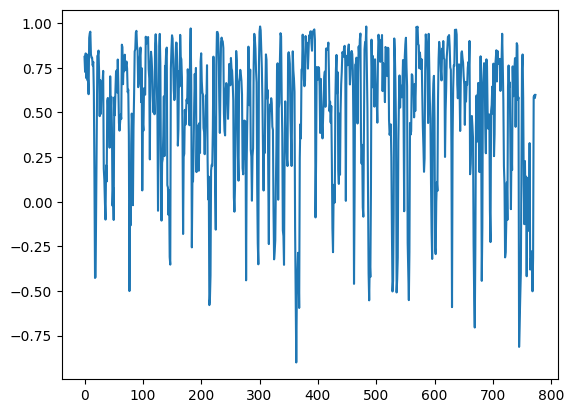

In [ ]:
# plot the corr_mt for the first subject run UA tr 1

plt.plot(df.loc[0,'corr_mt'])


In [ ]:
# Plot left mt, right mt and correlation between them as 3 subplots
fig, ax = plt.subplots(2,1,figsize=(20,8))
ax[0].plot(df.loc[df['subject']=='sub-01']['left_mt'].values[0],label='left_mt')
ax[0].plot(df.loc[df['subject']=='sub-01']['right_mt'].values[0],label='right_mt')
ax[0].legend()
ax[0].set_xlim([0,n_volumes])
ax[1].hlines(0,0,n_volumes,linestyle='dashed',color='black')
ax[1].plot(df.loc[df['subject']=='sub-01']['corr_mt'].values[0],label='correlation',color='grey')
ax[1].legend()
ax[1].set_xlim([0,n_volumes])
ax[1].set_ylim([-1,1])

fig.suptitle(f"Subject {subject_list[sub_idx]}, TR {tr_list[tr_idx]} s, Window size {window_size_tr} vols, Step size {step_size_tr} vols")

# centering at coherent switches

In [ ]:
# Settings
sub_idx = 4
tr_idx = 3
tr_list = [0.5, 0.75, 1, 2.5]
tr = tr_list[tr_idx]
window_size_tr = 4
run_type = 'UA'

task_label = f'task-{run_type}_acq-{round(tr*1000):04}_run-1'
events_file = os.path.join(data_dir, subject_list[sub_idx], 'func', f'{subject_list[sub_idx]}_{task_label}_events.tsv')

events = pd.read_csv(events_file, sep='\t')

# trim events to coherent and incoherent trial_types
events = events.loc[events['trial_type'].isin(['coherent','incoherent'])]
events = events.reset_index(drop=True)

# trim events with duration < 5 seconds
events = events.loc[events['duration']>=7.5]
events = events.reset_index(drop=True)

# get the indexes (based on the TR) for all coherent and incoherent trials
coherent_idx = events.loc[events['trial_type']=='coherent']['onset'].values/tr
coherent_idx = [int(x) for x in coherent_idx]
incoherent_idx = events.loc[events['trial_type']=='incoherent']['onset'].values/tr
incoherent_idx = [int(x) for x in incoherent_idx]

# number of coherent trials
n_coherent = len(coherent_idx)
n_incoherent = len(incoherent_idx)

In [ ]:
events

In [ ]:
# get the timecourse for the 6 points around the onset of the coherent and incoherent trials
# and plot the average timecourse for each trial type

# Get timecourse
tc = df.loc[(df['subject']==subject_list[sub_idx]) & (df['tr']==tr_list[tr_idx]) & (df['run']==run_list[0])][roi_list].values
n_volumes = tc[0,0].shape[0]

corr = np.zeros((n_coherent,window_size_tr*2+1))

for jj in range(n_coherent):

    idx = coherent_idx[jj]

    # left_mt timecourse
    a = tc[0,0][idx-window_size_tr:idx+window_size_tr*2]
    # right_mt timecourse
    b = tc[0,1][idx-window_size_tr:idx+window_size_tr*2]

    # correlation per window of window_size_tr
    for tt in range(0,window_size_tr*2+1):
        corr[jj,tt] = np.corrcoef(a[tt:tt+window_size_tr],b[tt:tt+window_size_tr])[0,1]
        
# plot average + sd of the n_coherent correlation trials
plt.plot(np.mean(corr,axis=0),label='coherent',marker='o')
plt.fill_between(np.arange(0,window_size_tr*2+1),np.mean(corr,axis=0)-np.std(corr,axis=0),np.mean(corr,axis=0)+np.std(corr,axis=0),alpha=0.5)
plt.vlines(window_size_tr,0,1,linestyle='dashed',color='black')
# write 'coherent' on x = 8 y = 0.8
plt.text(8,0.8,'coherent')
plt.ylabel('correlation')


In [ ]:
# get the timecourse for the 6 points around the onset of the incoherent trials
# and plot the average timecourse for each trial type

# Get timecourse
tc = df.loc[(df['subject']==subject_list[sub_idx]) & (df['tr']==tr_list[tr_idx]) & (df['run']==run_list[0])][roi_list].values
n_volumes = tc[0,0].shape[0]

corr = np.zeros((n_incoherent,window_size_tr*2+1))

for jj in range(n_incoherent):

    idx = incoherent_idx[jj]

    # left_mt timecourse
    a = tc[0,0][idx-window_size_tr:idx+window_size_tr*2]
    # right_mt timecourse
    b = tc[0,1][idx-window_size_tr:idx+window_size_tr*2]

    # correlation per window of window_size_tr
    for tt in range(0,window_size_tr*2+1):
        corr[jj,tt] = np.corrcoef(a[tt:tt+window_size_tr],b[tt:tt+window_size_tr])[0,1]
        
# plot average + sd of the n_coherent correlation trials
plt.plot(np.mean(corr,axis=0),label='incoherent',marker='o',color='red')
plt.fill_between(np.arange(0,window_size_tr*2+1),np.mean(corr,axis=0)-np.std(corr,axis=0),np.mean(corr,axis=0)+np.std(corr,axis=0),alpha=0.5,color='red')
plt.vlines(window_size_tr,0,1,linestyle='dashed',color='black')
# write 'coherent' on x = 8 y = 0.8
plt.text(8,0.8,'incoherent')
plt.ylabel('correlation')
